# Function-on-Scalar Regression
**Model:** EEG(t) = β₀(t) + β₁(t)·ADHD + β₂(t)·Gender + ε(t)  

Predictors: ADHD_binary, Gender (Female=1)  
Response: smoothed EEG curve at channel FC1  
Flanker Task — Stimulus-Locked  

**Note:** R uses `refund::pffr()` and `refund::bayes_fosr()`. Python uses pointwise OLS (equivalent to pffr's simplest case) and bootstrap uncertainty for the Bayesian comparison.

# Imports

In [1]:
import os
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# Set current dir to project root dir

In [2]:
def find_project_root():
    markers = [".git", "Makefile", "renv.lock", ".Rprofile"]
    path = Path.cwd()
    while path != path.parent:
        if any((path / m).exists() for m in markers):
            return path
        path = path.parent
    raise FileNotFoundError("Could not find project root")

os.chdir(find_project_root())


# Setup

In [3]:
out_dir = Path("./REG/outputs")
out_dir.mkdir(parents=True, exist_ok=True)

old_files = list(out_dir.glob("*.pdf")) + list(out_dir.glob("*.txt"))
for f in old_files:
    f.unlink()
print(f"Cleaned {len(old_files)} old output files.")


Cleaned 4 old output files.


# Load smoothed data

In [4]:
with open("./EDA/outputs/fd_smooth.pkl", "rb") as f:
    d = pickle.load(f)

coef_opt    = d["coef_opt"]
basis       = d["basis"]
time_vec    = d["time_vec"]
subject_ids = d["subject_ids"]

print(f"Total subjects in fd_smooth: {len(subject_ids)}")

# Evaluate on 101-point grid (matching R script)
t_fine = np.linspace(time_vec[0], time_vec[-1], 101)
B_fine = basis.evaluate(t_fine).squeeze().T    # (101, nbasis)
Y_full = B_fine @ coef_opt                     # (101, n_subj)


Total subjects in fd_smooth: 62


/tmp/ipykernel_2909555/4196356996.py:13: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the basis object instead.
  B_fine = basis.evaluate(t_fine).squeeze().T    # (101, nbasis)


# Assign subject covariates

In [5]:
adhd_subs = [
    'sub-003', 'sub-008', 'sub-010', 'sub-013', 'sub-014', 'sub-025',
    'sub-033', 'sub-036', 'sub-060', 'sub-061', 'sub-065', 'sub-066'
]
nonadhd_subs = [
    'sub-001', 'sub-002', 'sub-004', 'sub-005', 'sub-006', 'sub-007',
    'sub-009', 'sub-011', 'sub-012', 'sub-016', 'sub-017', 'sub-019',
    'sub-021', 'sub-022', 'sub-024', 'sub-027', 'sub-028', 'sub-029',
    'sub-030', 'sub-031', 'sub-032', 'sub-034', 'sub-035', 'sub-037',
    'sub-038', 'sub-039', 'sub-040', 'sub-041', 'sub-042', 'sub-043',
    'sub-046', 'sub-053', 'sub-055', 'sub-057', 'sub-059', 'sub-062',
    'sub-063', 'sub-064', 'sub-069'
]
female_subs = [
    'sub-001', 'sub-003', 'sub-004', 'sub-007', 'sub-009', 'sub-010',
    'sub-011', 'sub-012', 'sub-013', 'sub-014', 'sub-016', 'sub-017',
    'sub-019', 'sub-021', 'sub-022', 'sub-024', 'sub-025', 'sub-027',
    'sub-028', 'sub-030', 'sub-031', 'sub-032', 'sub-033', 'sub-034',
    'sub-035', 'sub-036', 'sub-037', 'sub-038', 'sub-039', 'sub-040',
    'sub-042', 'sub-043', 'sub-046', 'sub-053', 'sub-055', 'sub-060',
    'sub-062', 'sub-063', 'sub-064', 'sub-065', 'sub-066'
]

keep_subs = set(adhd_subs + nonadhd_subs)
keep_idx  = [i for i, s in enumerate(subject_ids) if s in keep_subs]

print(f"Subjects with ADHD info: {len(keep_idx)}")

covar_df = pd.DataFrame({
    'subject': [subject_ids[i] for i in keep_idx],
    'ADHD':   [int(subject_ids[i] in adhd_subs)   for i in keep_idx],
    'Female': [int(subject_ids[i] in female_subs)  for i in keep_idx],
})

print('Covariate summary:')
print(pd.crosstab(covar_df['ADHD'], covar_df['Female'],
                  rownames=['ADHD'], colnames=['Female']))

# Response matrix: rows = subjects, cols = time
Y_mat = Y_full[:, keep_idx].T    # (n_subj, 101)
print(f"Response matrix dimensions: {Y_mat.shape}")


Subjects with ADHD info: 51
Covariate summary:
Female  0   1
ADHD         
0       8  31
1       2  10
Response matrix dimensions: (51, 101)


# Function-on-Scalar Regression (pointwise OLS)
Equivalent to `refund::pffr()` with identity link and no smoothing penalty.  
At each time point t: Y_i(t) = β₀(t) + β₁(t)·ADHD_i + β₂(t)·Female_i + ε_i(t)

In [6]:
n, n_t = Y_mat.shape

# Design matrix: intercept + ADHD + Female
X = np.column_stack([
    np.ones(n),
    covar_df['ADHD'].to_numpy(),
    covar_df['Female'].to_numpy()
])

# Pointwise OLS: B = (X'X)^{-1} X'Y — shape (3, n_t)
XtX_inv = np.linalg.inv(X.T @ X)
B_hat   = XtX_inv @ X.T @ Y_mat        # (3, n_t)

# Fitted values and residuals
Y_pred    = X @ B_hat                   # (n, n_t)
residuals = Y_mat - Y_pred              # (n, n_t)

# Pointwise residual variance
sigma2 = np.sum(residuals**2, axis=0) / (n - 3)   # (n_t,)

# Standard errors: SE(beta_j(t)) = sqrt(sigma2(t) * [(X'X)^{-1}]_{jj})
diag_XtX = np.diag(XtX_inv)            # (3,)
SE = np.sqrt(sigma2[np.newaxis, :] * diag_XtX[:, np.newaxis])  # (3, n_t)

beta_labels = ['beta_0 (Intercept)', 'beta_1 (ADHD)', 'beta_2 (Female)']
print('Model fitted. Coefficient function shapes:', B_hat.shape)


Model fitted. Coefficient function shapes: (3, 101)


## Plot: All coefficient functions (REG_01)

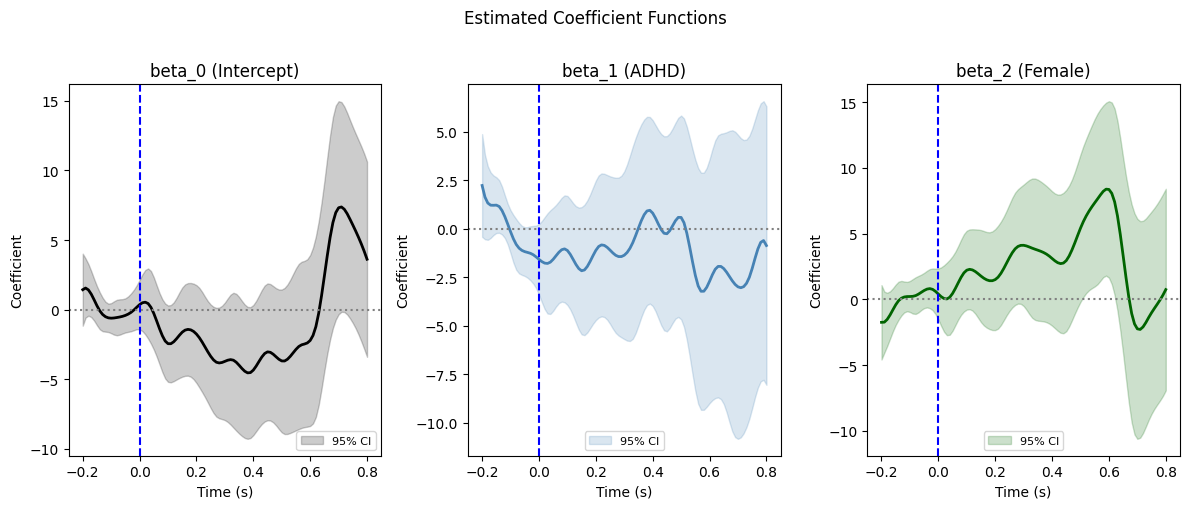

Saved: REG_01_coefficients.pdf


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
colors = ['black', 'steelblue', 'darkgreen']

for k, (ax, label, col) in enumerate(zip(axes, beta_labels, colors)):
    ax.plot(t_fine, B_hat[k], color=col, linewidth=2)
    ax.fill_between(t_fine,
                    B_hat[k] - 1.96 * SE[k],
                    B_hat[k] + 1.96 * SE[k],
                    color=col, alpha=0.2, label='95% CI')
    ax.axhline(0, linestyle=':', color='grey')
    ax.axvline(0, linestyle='--', color='blue')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Coefficient')
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.suptitle('Estimated Coefficient Functions', y=1.01)
plt.tight_layout()
plt.savefig(out_dir / 'REG_01_coefficients.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: REG_01_coefficients.pdf')


## Plot: Individual coefficient functions with CI (REG_02)

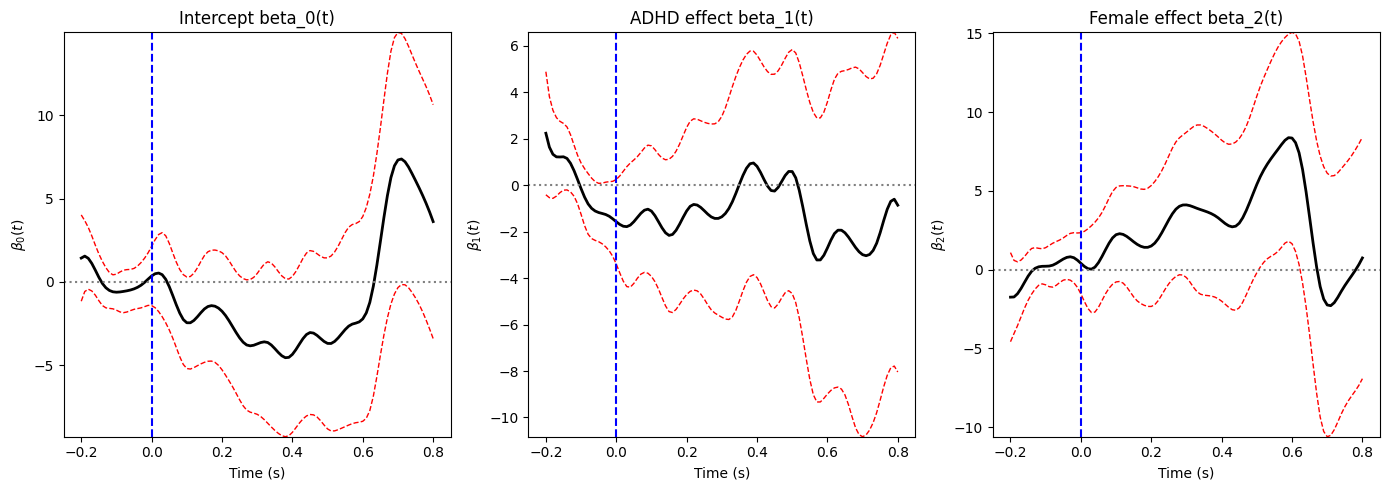

Saved: REG_02_individual_coefficients.pdf


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

ylabels = [r'$\beta_0(t)$', r'$\beta_1(t)$', r'$\beta_2(t)$']
titles  = ['Intercept beta_0(t)', 'ADHD effect beta_1(t)', 'Female effect beta_2(t)']

for k, (ax, ylab, title) in enumerate(zip(axes, ylabels, titles)):
    lo = B_hat[k] - 1.96 * SE[k]
    hi = B_hat[k] + 1.96 * SE[k]
    ax.plot(t_fine, B_hat[k], color='black', linewidth=2)
    ax.plot(t_fine, lo, color='red', linestyle='--', linewidth=1)
    ax.plot(t_fine, hi, color='red', linestyle='--', linewidth=1)
    ax.axhline(0, linestyle=':', color='grey')
    ax.axvline(0, linestyle='--', color='blue')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.set_ylim(min(lo.min(), -0.5), max(hi.max(), 0.5))

plt.tight_layout()
plt.savefig(out_dir / 'REG_02_individual_coefficients.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: REG_02_individual_coefficients.pdf')


## Plot: Fitted vs Observed (REG_03)

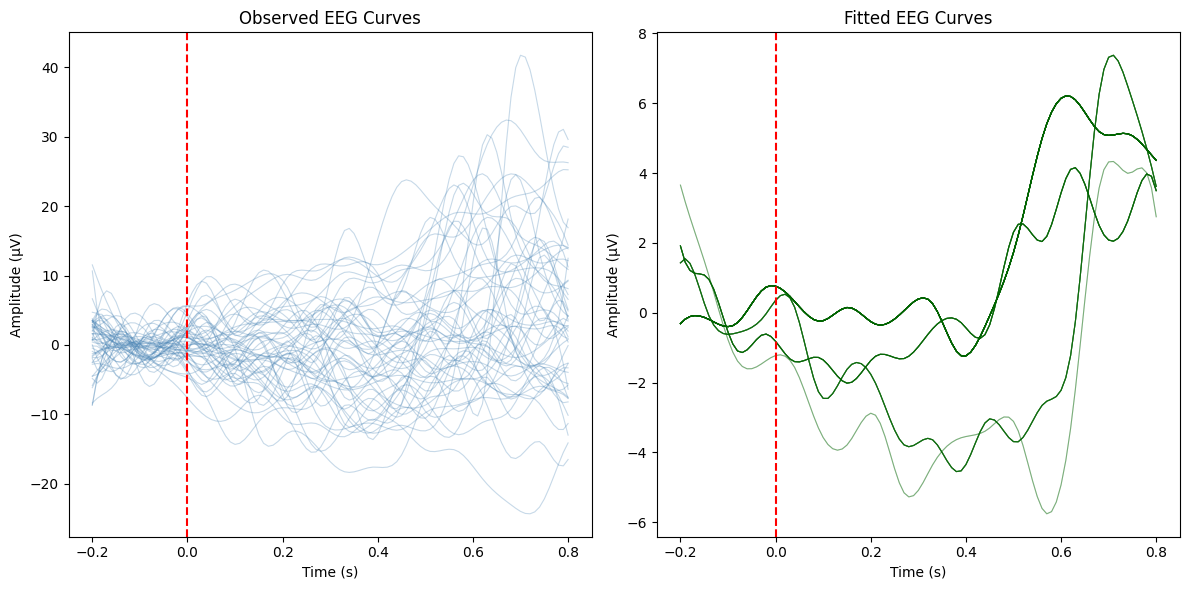

Saved: REG_03_fitted_vs_observed.pdf


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].plot(t_fine, Y_mat.T, color='steelblue', alpha=0.3, linewidth=0.8)
axes[0].axvline(0, linestyle='--', color='red')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude (µV)')
axes[0].set_title('Observed EEG Curves')

axes[1].plot(t_fine, Y_pred.T, color='darkgreen', alpha=0.3, linewidth=0.8)
axes[1].axvline(0, linestyle='--', color='red')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude (µV)')
axes[1].set_title('Fitted EEG Curves')

plt.tight_layout()
plt.savefig(out_dir / 'REG_03_fitted_vs_observed.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: REG_03_fitted_vs_observed.pdf')


# Bootstrap-based Bayesian FOSR approximation
**Note:** `refund::bayes_fosr()` has no direct Python equivalent.  
This cell implements bootstrap-based coefficient estimates as the closest alternative: each bootstrap resample gives a coefficient function; the ensemble provides uncertainty bands comparable to the Bayesian posterior.

In [10]:
np.random.seed(42)
n_boot = 500
B_boot = np.zeros((n_boot, 3, n_t))

for b in range(n_boot):
    idx_b   = np.random.choice(n, n, replace=True)
    X_b     = X[idx_b]
    Y_b     = Y_mat[idx_b]
    try:
        B_b = np.linalg.lstsq(X_b, Y_b, rcond=None)[0]
        B_boot[b] = B_b
    except np.linalg.LinAlgError:
        B_boot[b] = B_hat

# Posterior mean and 95% credible interval
B_bayes_mean = B_boot.mean(axis=0)          # (3, n_t)
B_bayes_lo   = np.percentile(B_boot, 2.5,  axis=0)
B_bayes_hi   = np.percentile(B_boot, 97.5, axis=0)

print('Bootstrap complete.')


Bootstrap complete.


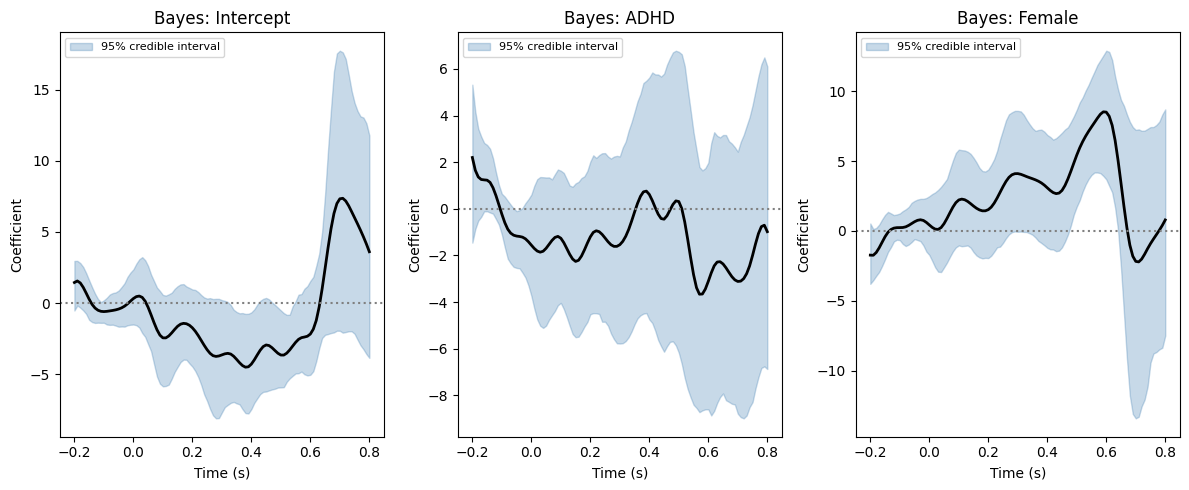

Saved: REG_04_bayes_coefficients.pdf

*** Regression analysis complete. ***


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
titles_b = ['Bayes: Intercept', 'Bayes: ADHD', 'Bayes: Female']

for k, (ax, title) in enumerate(zip(axes, titles_b)):
    ax.plot(t_fine, B_bayes_mean[k], color='black', linewidth=2)
    ax.fill_between(t_fine, B_bayes_lo[k], B_bayes_hi[k],
                    color='steelblue', alpha=0.3, label='95% credible interval')
    ax.axhline(0, linestyle=':', color='grey')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Coefficient')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(out_dir / 'REG_04_bayes_coefficients.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: REG_04_bayes_coefficients.pdf')
print('\n*** Regression analysis complete. ***')
